# 02 — Activity Cliffs & Structure–Activity Consistency (Tyk2)

**Goal:** quantify the SAR landscape from notebook 01's 3,353-molecule set, find the **activity cliffs** (pairs that are structurally near-identical but differ sharply in potency), and test the failure hypothesis from notebook 01: *that similarity-based prediction works within a chemotype but breaks across chemotypes and at cliffs.*

Activity cliffs are where structure-based and similarity-based methods fail — docking scores and QSAR both assume 'similar structure → similar activity,' and cliffs are the explicit violation. Identifying them is the difference between running a QSAR pipeline and understanding where it will mislead a project.

This reuses fingerprint/similarity machinery you know from IC50Forge — but here in service of *target-specific SAR judgment*, not a standalone model.

## 1. Load the cleaned SAR set from notebook 01

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import DataStructs, rdFingerprintGenerator, Draw

df = pd.read_csv('../data/tyk2_chembl_sar.csv')
print('Molecules:', len(df), '| pIC50 range:', round(df.pIC50.min(), 2), '-', round(df.pIC50.max(), 2))
df.head()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Molecules: 3353 | pIC50 range: 3.81 - 10.8


,molecule_chembl_id,canonical_smiles,pIC50,n_measurements
0,CHEMBL1076700,Cc1cc(Nc2nc3cccc(-c4cc(F)c(CN5CCOCC5)c(F)c4)c3...,7.013228,1
1,CHEMBL1078178,N#CCNC(=O)c1ccc(-c2ccnc(Nc3ccc(N4CCOCC4)cc3)n2...,7.522879,4
2,CHEMBL1080159,Cc1cc(Nc2nc3cccc(-c4cc(F)c(CN5CCOCC5)c(F)c4)c3...,6.698970,1
3,CHEMBL1081290,COc1cc(Nc2nc3cccc(-c4ccccc4)c3o2)cc(OC)c1OC,5.468521,1
4,CHEMBL1081443,COc1cc(Nc2nc3cccc(-c4ccccn4)c3o2)cc(OC)c1OC,6.193820,1


## 2. Compute Morgan fingerprints

ECFP4-equivalent (radius 2, 2048 bits) via the modern RDKit generator. We drop molecules RDKit can't parse.

In [2]:
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

mols, fps, keep_idx = [], [], []
for i, smi in enumerate(df['canonical_smiles']):
    m = Chem.MolFromSmiles(smi)
    if m is not None:
        mols.append(m)
        fps.append(gen.GetFingerprint(m))
        keep_idx.append(i)

df = df.iloc[keep_idx].reset_index(drop=True)
print(f'Parsed {len(fps)} / {len(keep_idx)} molecules with valid fingerprints')

Parsed 3353 / 3353 molecules with valid fingerprints


## 3. Find activity cliffs via SALI

The **Structure–Activity Landscape Index** for a pair (i, j):

$$ \mathrm{SALI}_{ij} = \frac{|\,\mathrm{pIC50}_i - \mathrm{pIC50}_j\,|}{1 - \mathrm{Tanimoto}(i, j)} $$

High SALI = very similar structures (Tanimoto near 1, small denominator) with a large potency gap (large numerator) = an **activity cliff**. We scan all pairs above a similarity threshold (cliffs only make sense for *similar* pairs) and rank by SALI.

For 3,000+ molecules the full pair matrix is ~5M pairs — feasible, but we only keep pairs with Tanimoto ≥ 0.6 (below that, 'cliff' is meaningless — they're just different molecules).

In [3]:
# Bulk Tanimoto is fast; we iterate the upper triangle and keep high-similarity pairs.
SIM_THRESHOLD = 0.6

pairs = []
pic50 = df['pIC50'].values
ids = df['molecule_chembl_id'].values
n = len(fps)

for i in range(n):
    # BulkTanimoto: fp[i] vs all fp[i+1:]
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])
    for offset, sim in enumerate(sims):
        if sim >= SIM_THRESHOLD:
            j = i + 1 + offset
            dpot = abs(pic50[i] - pic50[j])
            sali = dpot / (1 - sim) if sim < 1.0 else np.inf
            pairs.append((ids[i], ids[j], sim, pic50[i], pic50[j], dpot, sali))

pairs_df = pd.DataFrame(pairs, columns=[
    'mol_i', 'mol_j', 'tanimoto', 'pIC50_i', 'pIC50_j', 'delta_pIC50', 'SALI'])
pairs_df = pairs_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['SALI'])
print(f'{len(pairs_df)} similar pairs (Tanimoto >= {SIM_THRESHOLD})')
print(f'Pairs that are activity cliffs (delta_pIC50 >= 2, Tanimoto >= 0.8): '
      f"{len(pairs_df[(pairs_df.delta_pIC50 >= 2) & (pairs_df.tanimoto >= 0.8)])}")

67344 similar pairs (Tanimoto >= 0.6)
Pairs that are activity cliffs (delta_pIC50 >= 2, Tanimoto >= 0.8): 73


In [4]:
# The steepest cliffs: high similarity, big potency gap.
cliffs = pairs_df.sort_values('SALI', ascending=False).head(15)
cliffs[['mol_i', 'mol_j', 'tanimoto', 'pIC50_i', 'pIC50_j', 'delta_pIC50', 'SALI']].round(2)

,mol_i,mol_j,tanimoto,pIC50_i,pIC50_j,delta_pIC50,SALI
63205,CHEMBL5952122,CHEMBL6024306,0.94,6.51,8.95,2.44,42.26
41038,CHEMBL5804527,CHEMBL5928913,0.90,9.38,5.85,3.53,35.91
36101,CHEMBL5783727,CHEMBL5894873,0.90,9.24,5.96,3.29,32.85
59309,CHEMBL5909283,CHEMBL6048693,0.87,9.16,6.05,3.11,24.49
48668,CHEMBL5841789,CHEMBL5917540,0.84,5.56,9.55,3.99,24.38
57889,CHEMBL5898638,CHEMBL6060706,0.82,5.15,9.29,4.15,23.64
22794,CHEMBL4763801,CHEMBL4787133,0.94,5.92,7.37,1.45,23.61
33189,CHEMBL5771209,CHEMBL6052223,0.93,7.34,5.70,1.64,22.67
66594,CHEMBL6008834,CHEMBL6058534,0.86,5.93,8.97,3.04,21.64
364,CHEMBL2181315,CHEMBL2181316,0.91,5.28,7.15,1.87,21.52


## 4. Visualize the steepest cliffs

Draw the top cliff pairs side by side. The point: these look almost identical, yet their potencies differ by orders of magnitude. A similarity-based model predicts them as equally active — and is badly wrong. *These are the molecules that would burn a project relying on naive similarity.*

Steepest cliff: Tanimoto=0.94, delta_pIC50=2.4, SALI=42.3


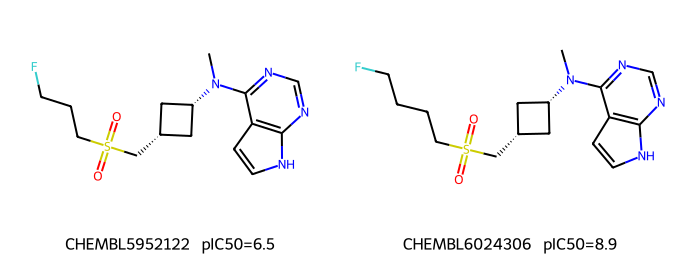

In [5]:
def draw_cliff(row):
    smi_i = df.loc[df.molecule_chembl_id == row.mol_i, 'canonical_smiles'].iloc[0]
    smi_j = df.loc[df.molecule_chembl_id == row.mol_j, 'canonical_smiles'].iloc[0]
    mi, mj = Chem.MolFromSmiles(smi_i), Chem.MolFromSmiles(smi_j)
    legends = [f'{row.mol_i}  pIC50={row.pIC50_i:.1f}',
               f'{row.mol_j}  pIC50={row.pIC50_j:.1f}']
    return Draw.MolsToGridImage([mi, mj], legends=legends, molsPerRow=2, subImgSize=(340, 260))

top_cliff = cliffs.iloc[0]
print(f'Steepest cliff: Tanimoto={top_cliff.tanimoto:.2f}, '
      f'delta_pIC50={top_cliff.delta_pIC50:.1f}, SALI={top_cliff.SALI:.1f}')
draw_cliff(top_cliff)

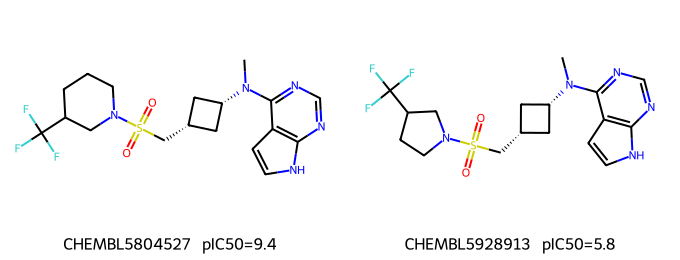

In [6]:
# A couple more of the top cliffs for the writeup.
draw_cliff(cliffs.iloc[1])

## 5. The SAR landscape overall

Plot potency-difference vs structural similarity for all pairs. Most similar pairs have small potency differences (the 'smooth' SAR that models handle). The cliffs are the upper-right outliers: high similarity, high potency difference. This one figure summarizes how predictable this target's SAR is — and where it isn't.

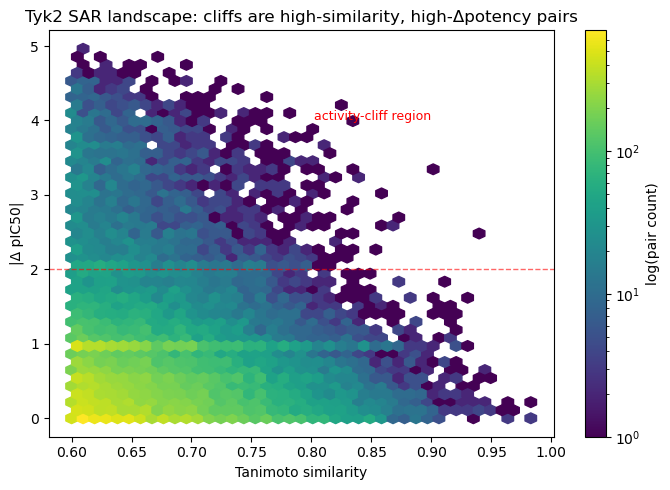

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
# hexbin handles the ~millions of pairs; sample if needed for speed
sample = pairs_df.sample(min(50000, len(pairs_df)), random_state=0)
hb = ax.hexbin(sample['tanimoto'], sample['delta_pIC50'], gridsize=40,
               bins='log', cmap='viridis')
ax.set_xlabel('Tanimoto similarity')
ax.set_ylabel('|Δ pIC50|')
ax.set_title('Tyk2 SAR landscape: cliffs are high-similarity, high-Δpotency pairs')
# mark the cliff region
ax.axhline(2, color='red', ls='--', lw=1, alpha=0.6)
ax.annotate('activity-cliff region', xy=(0.9, 4), color='red', fontsize=9, ha='right')
fig.colorbar(hb, label='log(pair count)')
fig.tight_layout()
fig.savefig('../figures/sar_landscape.png', dpi=200)
plt.show()

## 6. Test the failure hypothesis: does similarity predict activity?

The direct test of notebook 01's claim. For each molecule, predict its pIC50 as the activity of its **nearest structural neighbor** (the naive similarity assumption). Then compare predicted vs actual. Where this works, SAR is smooth; where it fails (the cliffs), similarity-based methods — including docking rank-ordering — will mislead.

This is a leave-one-out 1-nearest-neighbor test in fingerprint space.

In [8]:
# For each molecule, find its single most-similar other molecule and use that neighbor's
# pIC50 as the prediction (1-NN in Tanimoto space).
pred, actual, nn_sim = [], [], []
for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    sims[i] = -1  # exclude self
    j = int(np.argmax(sims))
    pred.append(pic50[j])
    actual.append(pic50[i])
    nn_sim.append(sims[j])

pred, actual, nn_sim = np.array(pred), np.array(actual), np.array(nn_sim)
err = np.abs(pred - actual)
print(f'1-NN similarity-based prediction over {n} molecules:')
print(f'  MAE  = {err.mean():.2f} pIC50 units')
print(f'  RMSE = {np.sqrt((err**2).mean()):.2f} pIC50 units')
# Restrict to close neighbours: prediction should be BETTER when a near-identical analog exists
close = nn_sim >= 0.8
print(f'\n  For molecules WITH a close analog (NN Tanimoto >= 0.8, n={close.sum()}):')
print(f'    MAE = {err[close].mean():.2f}  <- smooth-SAR regime')
print(f'  For molecules WITHOUT (NN Tanimoto < 0.8, n={(~close).sum()}):')
print(f'    MAE = {err[~close].mean():.2f}  <- harder to predict')

1-NN similarity-based prediction over 3353 molecules:
  MAE  = 0.53 pIC50 units
  RMSE = 0.80 pIC50 units

  For molecules WITH a close analog (NN Tanimoto >= 0.8, n=2082):
    MAE = 0.48  <- smooth-SAR regime
  For molecules WITHOUT (NN Tanimoto < 0.8, n=1271):
    MAE = 0.62  <- harder to predict


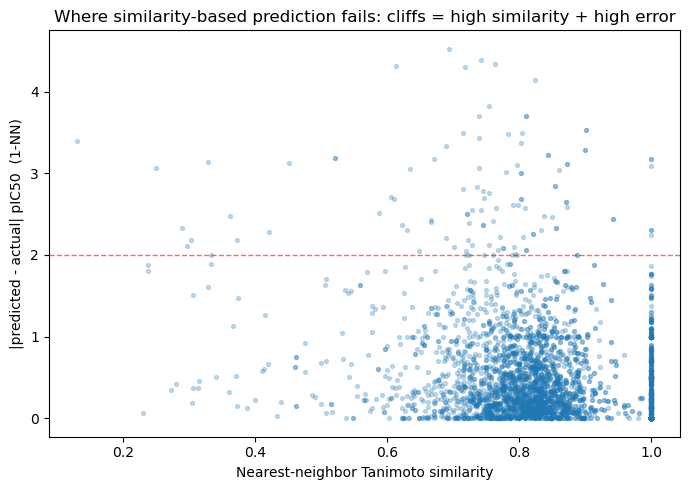

In [9]:
# Plot: prediction error vs how close the nearest neighbor is.
# The cliffs live at high NN-similarity but high error — the counterexamples.
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(nn_sim, err, s=8, alpha=0.25)
ax.set_xlabel('Nearest-neighbor Tanimoto similarity')
ax.set_ylabel('|predicted - actual| pIC50  (1-NN)')
ax.set_title('Where similarity-based prediction fails: cliffs = high similarity + high error')
ax.axhline(2, color='red', ls='--', lw=1, alpha=0.6)
fig.tight_layout()
fig.savefig('../figures/nn_prediction_error.png', dpi=200)
plt.show()

## 7. Findings & interpretation (fill in — the core deliverable)

Findings
Tyk2's SAR is, on average, smooth and structure-predictable. A crude 1-nearest-neighbor predictor (assign each molecule the potency of its closest structural analog) achieves MAE 0.53 pIC50 across all 3,353 molecules, improving to 0.48 for molecules with a close analog (NN Tanimoto ≥ 0.8). For congeneric prediction this is good news — it's consistent with why physics-based methods converge well on smooth homologation series like the JACS benchmark's ejm_ ladder.
But that smooth average conceals 73 activity cliffs — pairs with Tanimoto ≥ 0.8 differing by ≥ 2 pIC50 units. The NN-error plot makes the danger explicit: the vertical spread of high-error points at Tanimoto ≈ 1.0 are compounds where a near-identical neighbor gives a 2–3 log-unit wrong prediction. These are the cases where one would be most confident and most wrong.
Two cliffs illustrate the mechanism, both on the pyrrolopyrimidine–sulfonyl chemotype:

One-methylene sulfone chain (CHEMBL5952122 vs CHEMBL6024306, Tanimoto 0.94): extending the fluoroalkyl sulfone chain by a single CH₂ shifts potency ~275× (pIC50 6.5 → 8.9).
Ring size on the sulfonamide (CHEMBL5804527 vs CHEMBL5928913): CF₃-piperidine → CF₃-pyrrolidine collapses potency ~4000× (pIC50 9.4 → 5.8).

Both cliffs sit on the sulfonyl-bearing region — the substituent that recurs across both potent chemotypes (notebook 01) and likely engages the polar pocket near the catalytic Lys930. These are precisely the effects a fixed-charge docking/scoring function handles poorly: sub-ångström differences in how a polar group reaches a subpocket, and conformational/electrostatic changes in sulfonyl presentation from ring geometry. A scoring function tuned to smooth trends will score both cliff members similarly and mis-rank them.
Interpretation. Aggregate predictability masks the failure cases that determine project success. Cheap similarity/docking methods are reliable on the smooth majority but fail — confidently — at the cliffs. This is exactly where physics-based free-energy methods justify their cost: the value of FEP is not on the easy congeneric edges (where similarity already works) but on the cliffs, where explicit sampling of the changed interaction is the only way to get the sign of the effect right.

## 8. Save cliff table

Persist the identified cliffs for the README / writeup.

In [ ]:
cliffs.round(3).to_csv('../data/tyk2_activity_cliffs.csv', index=False)
print('Saved ../data/tyk2_activity_cliffs.csv')